**Influence Maximization via Metaheuristic Optimization**

In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import warnings
warnings.filterwarnings('ignore')

**Datasets**

In [4]:
def load_data(path, is_directed=False):
    graph_type = nx.DiGraph() if is_directed else nx.Graph()
    G = nx.read_edgelist(path, create_using=graph_type, nodetype=int)
    print(f"Nodes: {G.number_of_nodes():,}")
    print(f"Edges: {G.number_of_edges():,}")
    print(f"Density: {nx.density(G):.6f}")
    if is_directed:
        print(f"Weakly Connected Components: {nx.number_weakly_connected_components(G):,}")
    else:
        print(f"Connected Components: {nx.number_connected_components(G):,}")

    return G
G1 = load_data("/content/drive/MyDrive/Explo/CA-GrQc.txt", is_directed=True)
G2 = load_data("/content/drive/MyDrive/Explo/Wiki-Vote.txt", is_directed=True)
G3 = load_data("/content/drive/MyDrive/Explo/facebook_combined.txt", is_directed=True)

Nodes: 5,242
Edges: 28,980
Density: 0.001055
Weakly Connected Components: 355
Nodes: 7,115
Edges: 103,689
Density: 0.002049
Weakly Connected Components: 24
Nodes: 4,039
Edges: 88,234
Density: 0.005410
Weakly Connected Components: 1


**The Diffusion Model**

In [5]:
def independent_cascade(G, seed_set, probability=0.1, mc_simulations=100):
    total_spread = 0
    for _ in range(mc_simulations):
        active_nodes = set(seed_set)
        newly_active = list(seed_set)
        while newly_active:
            current_node = newly_active.pop(0)
            for neighbor in G.neighbors(current_node):
                if neighbor not in active_nodes:
                    if np.random.rand() < probability:
                        active_nodes.add(neighbor)
                        newly_active.append(neighbor)
        total_spread += len(active_nodes)
    return total_spread / mc_simulations

**Baseline Algorithms**

In [6]:
def random_selection(G, k, mc_sims=20):
    seed_set = random.sample(list(G.nodes()), k)
    return independent_cascade(G, seed_set, 0.1, mc_sims)

def degree_centrality(G, k, mc_sims=20):
    # Sort nodes by their out-degree (number of outgoing connections)
    sorted_nodes = sorted(G.out_degree(), key=lambda x: x[1], reverse=True)
    seed_set = [node[0] for node in sorted_nodes[:k]]
    return independent_cascade(G, seed_set, 0.1, mc_sims)

def greedy_algorithm(G, k, mc_sims=20):
    seed_set = []
    all_nodes = list(G.nodes())

    for _ in range(k):
        best_node = None
        best_marginal_spread = -1

        for node in all_nodes:
            if node not in seed_set:
                current_test_set = seed_set + [node]
                spread = independent_cascade(G, current_test_set, 0.1, mc_sims)

                if spread > best_marginal_spread:
                    best_marginal_spread = spread
                    best_node = node

        seed_set.append(best_node)

    return independent_cascade(G, seed_set, 0.1, mc_sims)


**The Metaheuristic (Genetic Algorithm)**

In [7]:
def tournament_selection(population, fitness_scores, tournament_size=3):
    selected_indices = random.sample(range(len(population)), tournament_size)
    best_index = selected_indices[0]
    for idx in selected_indices[1:]:
        if fitness_scores[idx] > fitness_scores[best_index]:
            best_index = idx
    return population[best_index]

def crossover(parent_a, parent_b, all_graph_nodes, k):
    midpoint = k // 2
    child = list(parent_a[:midpoint]) + list(parent_b[midpoint:])
    child_set = set(child)
    if len(child_set) < k:
        available_nodes = list(set(all_graph_nodes) - child_set)
        missing_count = k - len(child_set)
        replacements = random.sample(available_nodes, missing_count)
        child_set.update(replacements)

    return list(child_set)

def mutate(chromosome, all_graph_nodes, mutation_rate=0.1):
    if random.random() < mutation_rate:
        drop_index = random.randint(0, len(chromosome) - 1)
        available_nodes = list(set(all_graph_nodes) - set(chromosome))
        chromosome[drop_index] = random.choice(available_nodes)
    return chromosome

def run_genetic_algorithm_with_history(G, k, pop_size=30, generations=20, mc_sims=15):
    all_graph_nodes = list(G.nodes())
    population = [random.sample(all_graph_nodes, k) for _ in range(pop_size)]

    best_overall_spread = 0
    best_overall_seed_set = None

    history_best = []
    history_avg = []

    for gen in range(generations):
        # 1. Evaluate Fitness
        fitness_scores = [independent_cascade(G, chromo, 0.1, mc_sims) for chromo in population]

        # 2. Record generation statistics
        current_best = max(fitness_scores)
        current_avg = sum(fitness_scores) / len(fitness_scores)

        history_best.append(current_best)
        history_avg.append(current_avg)

        if current_best > best_overall_spread:
            best_overall_spread = current_best
            best_overall_seed_set = population[fitness_scores.index(current_best)]

        # 3. Create next generation (Elitism + Tournament + Crossover + Mutation)
        next_gen = [best_overall_seed_set]

        while len(next_gen) < pop_size:
            p_a = tournament_selection(population, fitness_scores)
            p_b = tournament_selection(population, fitness_scores)
            child = crossover(p_a, p_b, all_graph_nodes, k)
            child = mutate(child, all_graph_nodes)
            next_gen.append(child)

        population = next_gen

    return best_overall_spread, history_best, history_avg

**Experimental Setup & Execution**

In [10]:
if __name__ == "__main__":
    k_values = [2, 4, 6, 8, 10]

    # Data tracking
    results_spread = {"Greedy": [], "GA": [], "Degree": [], "Random": []}
    results_time = {"Greedy": [], "GA": [], "Degree": [], "Random": []}

    print("Starting experiment. This may take a few minutes...")
    for k in k_values:
        print(f"\nEvaluating Seed Set Size (k) = {k}")

        # 1. Random
        start = time.time()
        results_spread["Random"].append(random_selection(G1, k))
        results_time["Random"].append(time.time() - start)

        # 2. Degree Centrality
        start = time.time()
        results_spread["Degree"].append(degree_centrality(G1, k))
        results_time["Degree"].append(time.time() - start)

        # 3. Genetic Algorithm
        start = time.time()
        results_spread["GA"].append(run_genetic_algorithm_with_history(G1, k))
        results_time["GA"].append(time.time() - start)

        # 4. Greedy
        start = time.time()
        results_spread["Greedy"].append(greedy_algorithm(G1, k))
        results_time["Greedy"].append(time.time() - start)


Starting experiment. This may take a few minutes...

Evaluating Seed Set Size (k) = 2

Evaluating Seed Set Size (k) = 4

Evaluating Seed Set Size (k) = 6

Evaluating Seed Set Size (k) = 8

Evaluating Seed Set Size (k) = 10


**Results & Visualization**

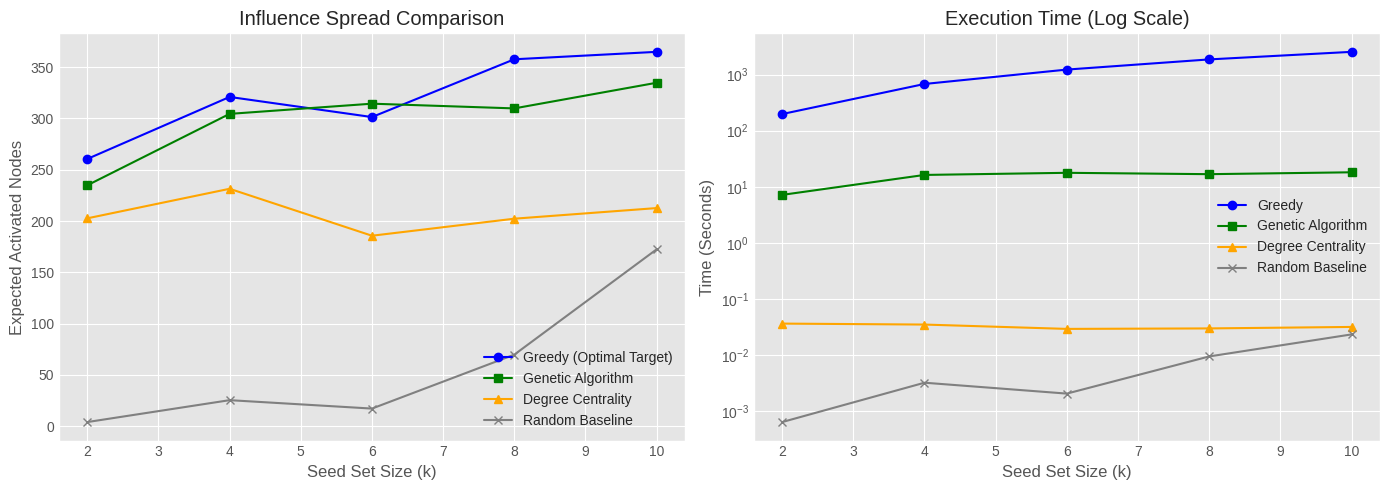

In [14]:
if __name__ == "__main__":
    plt.style.use('ggplot')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Spread Comparison
    ax1.plot(k_values, results_spread["Greedy"], marker='o', label='Greedy (Optimal Target)', color='blue')
    ga_scores_only = [res[0] for res in results_spread["GA"]]
    ax1.plot(k_values, ga_scores_only, marker='s', label='Genetic Algorithm', color='green')
    ax1.plot(k_values, results_spread["Degree"], marker='^', label='Degree Centrality', color='orange')
    ax1.plot(k_values, results_spread["Random"], marker='x', label='Random Baseline', color='gray')
    ax1.set_title('Influence Spread Comparison')
    ax1.set_xlabel('Seed Set Size (k)')
    ax1.set_ylabel('Expected Activated Nodes')
    ax1.legend()

    # Plot 2: Time Comparison (Log Scale)
    ax2.plot(k_values, results_time["Greedy"], marker='o', label='Greedy', color='blue')
    ax2.plot(k_values, results_time["GA"], marker='s', label='Genetic Algorithm', color='green')
    ax2.plot(k_values, results_time["Degree"], marker='^', label='Degree Centrality', color='orange')
    ax2.plot(k_values, results_time["Random"], marker='x', label='Random Baseline', color='gray')
    ax2.set_title('Execution Time (Log Scale)')
    ax2.set_xlabel('Seed Set Size (k)')
    ax2.set_ylabel('Time (Seconds)')
    ax2.set_yscale('log')
    ax2.legend()

    plt.tight_layout()
    plt.show()

Running Genetic Algorithm to track convergence...


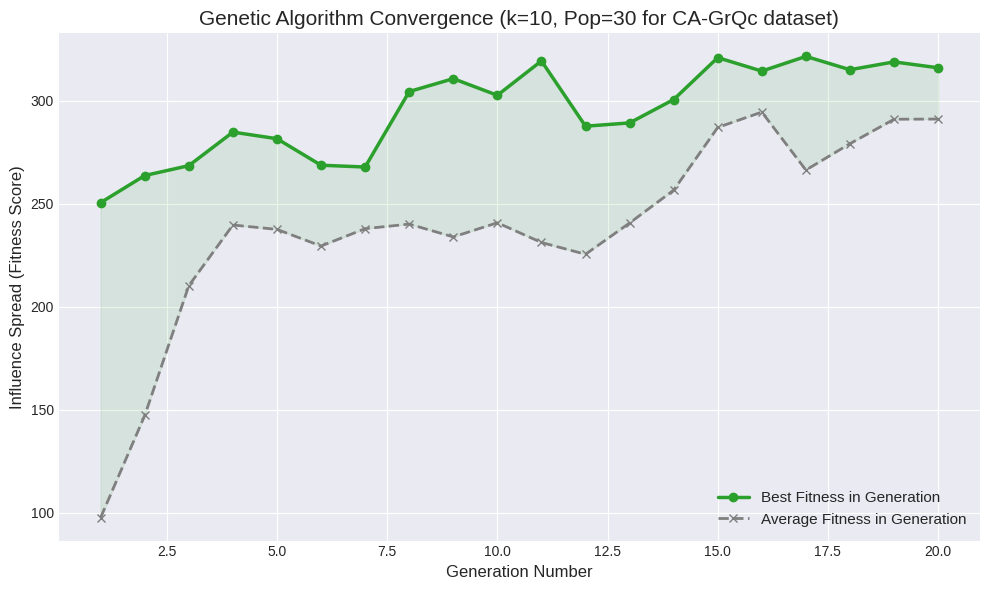

Algorithm converged on an expected spread of: 321.47


In [9]:
k_target = 10
generations = 20
population_size = 30
print("Running Genetic Algorithm to track convergence...")
final_score, best_curve, avg_curve = run_genetic_algorithm_with_history(
    G1,
    k=k_target,
    pop_size=population_size,
    generations=generations
)
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-darkgrid')
gen_x = list(range(1, generations + 1))
plt.plot(gen_x, best_curve, marker='o', color='#2ca02c', linewidth=2.5, label='Best Fitness in Generation')
plt.plot(gen_x, avg_curve, marker='x', color='#7f7f7f', linewidth=2, linestyle='--', label='Average Fitness in Generation')
plt.title(f'Genetic Algorithm Convergence (k={k_target}, Pop={population_size} for CA-GrQc dataset)', fontsize=15)
plt.xlabel('Generation Number', fontsize=12)
plt.ylabel('Influence Spread (Fitness Score)', fontsize=12)
plt.fill_between(gen_x, avg_curve, best_curve, color='#2ca02c', alpha=0.1)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()
print(f"Algorithm converged on an expected spread of: {final_score:.2f}")

Running Genetic Algorithm to track convergence...


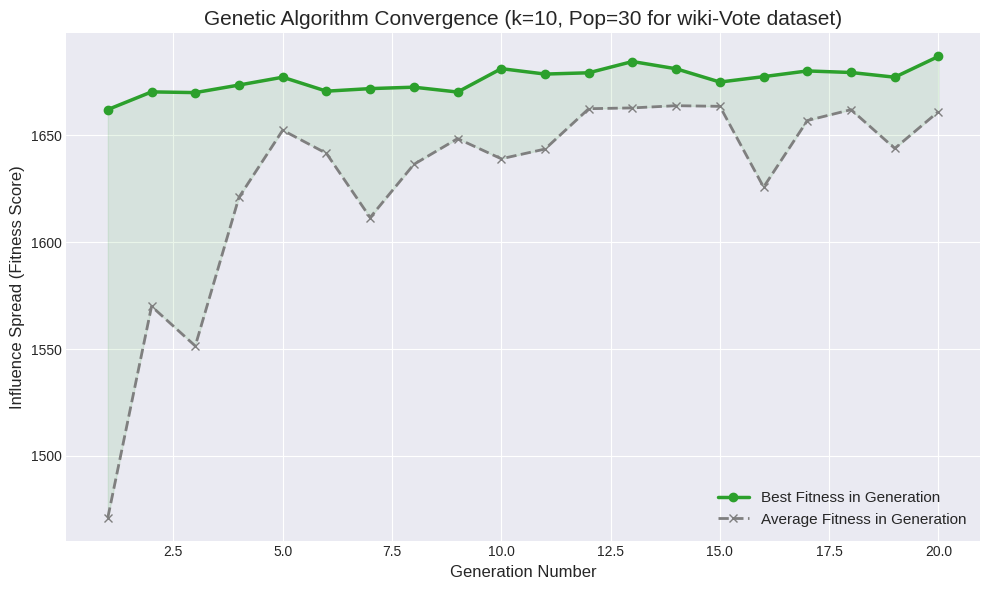

Algorithm converged on an expected spread of: 1686.87


In [ ]:
k_target = 10
generations = 20
population_size = 30
print("Running Genetic Algorithm to track convergence...")
final_score, best_curve, avg_curve = run_genetic_algorithm_with_history(
    G2,
    k=k_target,
    pop_size=population_size,
    generations=generations
)
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-darkgrid')
gen_x = list(range(1, generations + 1))
plt.plot(gen_x, best_curve, marker='o', color='#2ca02c', linewidth=2.5, label='Best Fitness in Generation')
plt.plot(gen_x, avg_curve, marker='x', color='#7f7f7f', linewidth=2, linestyle='--', label='Average Fitness in Generation')
plt.title(f'Genetic Algorithm Convergence (k={k_target}, Pop={population_size} for wiki-Vote dataset)', fontsize=15)
plt.xlabel('Generation Number', fontsize=12)
plt.ylabel('Influence Spread (Fitness Score)', fontsize=12)
plt.fill_between(gen_x, avg_curve, best_curve, color='#2ca02c', alpha=0.1)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()
print(f"Algorithm converged on an expected spread of: {final_score:.2f}")

Running Genetic Algorithm to track convergence...


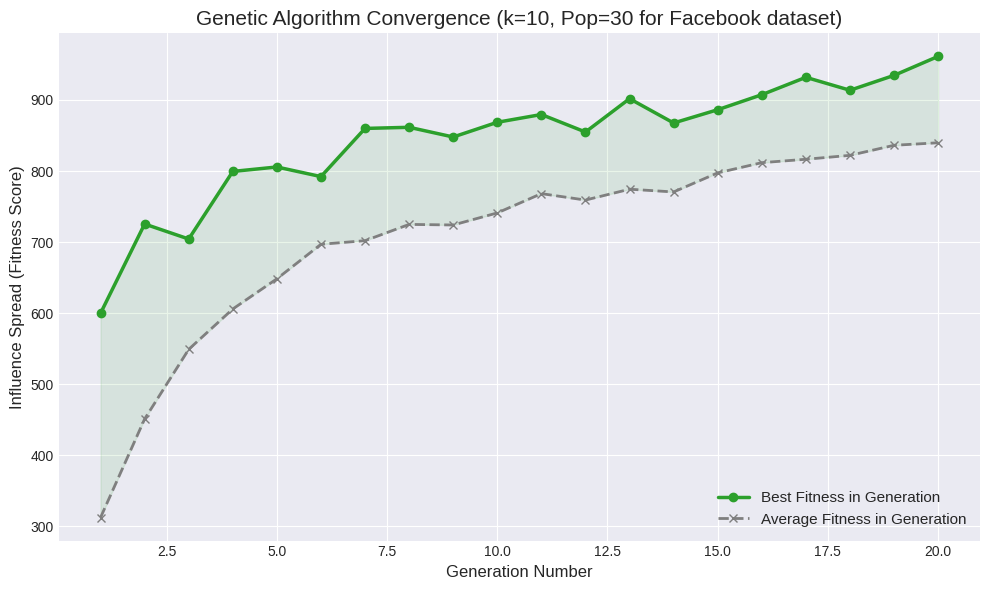

Algorithm converged on an expected spread of: 961.33


In [ ]:
k_target = 10
generations = 20
population_size = 30
print("Running Genetic Algorithm to track convergence...")
final_score, best_curve, avg_curve = run_genetic_algorithm_with_history(
    G3,
    k=k_target,
    pop_size=population_size,
    generations=generations
)
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-darkgrid')
gen_x = list(range(1, generations + 1))
plt.plot(gen_x, best_curve, marker='o', color='#2ca02c', linewidth=2.5, label='Best Fitness in Generation')
plt.plot(gen_x, avg_curve, marker='x', color='#7f7f7f', linewidth=2, linestyle='--', label='Average Fitness in Generation')
plt.title(f'Genetic Algorithm Convergence (k={k_target}, Pop={population_size} for Facebook dataset)', fontsize=15)
plt.xlabel('Generation Number', fontsize=12)
plt.ylabel('Influence Spread (Fitness Score)', fontsize=12)
plt.fill_between(gen_x, avg_curve, best_curve, color='#2ca02c', alpha=0.1)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()
print(f"Algorithm converged on an expected spread of: {final_score:.2f}")

Starting Grid Search (k=8)...
Testing Population Size: 20
  -> Mutation: 1.0% | Spread: 304.5 | Time: 3.6s
  -> Mutation: 5.0% | Spread: 340.7 | Time: 6.0s
  -> Mutation: 10.0% | Spread: 270.3 | Time: 3.5s
  -> Mutation: 20.0% | Spread: 322.6 | Time: 3.3s
  -> Mutation: 30.0% | Spread: 308.2 | Time: 4.3s
Testing Population Size: 40
  -> Mutation: 1.0% | Spread: 314.3 | Time: 9.1s
  -> Mutation: 5.0% | Spread: 327.2 | Time: 10.2s
  -> Mutation: 10.0% | Spread: 289.5 | Time: 6.9s
  -> Mutation: 20.0% | Spread: 321.9 | Time: 9.4s
  -> Mutation: 30.0% | Spread: 293.9 | Time: 8.1s
Testing Population Size: 60
  -> Mutation: 1.0% | Spread: 312.7 | Time: 13.1s
  -> Mutation: 5.0% | Spread: 307.0 | Time: 11.9s
  -> Mutation: 10.0% | Spread: 309.5 | Time: 13.2s
  -> Mutation: 20.0% | Spread: 346.0 | Time: 13.8s
  -> Mutation: 30.0% | Spread: 331.6 | Time: 12.2s


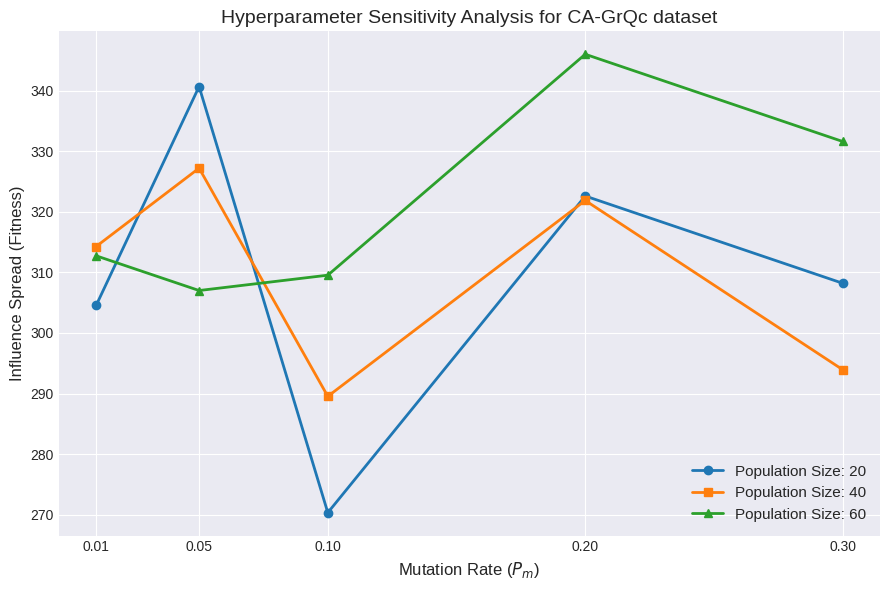

In [ ]:
def tuned_genetic_algorithm(G, k, pop_size, generations, mutation_rate, mc_sims=15):
    all_nodes = list(G.nodes())
    population = [random.sample(all_nodes, k) for _ in range(pop_size)]
    best_spread = 0

    for gen in range(generations):
        fitness_scores = [independent_cascade(G, chromo, 0.1, mc_sims) for chromo in population]
        max_fitness = max(fitness_scores)

        if max_fitness > best_spread:
            best_spread = max_fitness
            best_seed_set = population[fitness_scores.index(max_fitness)]

        next_gen = [best_seed_set] # Elitism

        while len(next_gen) < pop_size:
            p_a = tournament_selection(population, fitness_scores)
            p_b = tournament_selection(population, fitness_scores)
            child = crossover(p_a, p_b, all_nodes, k)

            # --- DYNAMIC MUTATION ---
            if random.random() < mutation_rate:
                drop_idx = random.randint(0, len(child) - 1)
                avail = list(set(all_nodes) - set(child))
                child[drop_idx] = random.choice(avail)

            next_gen.append(child)
        population = next_gen

    return best_spread

mutation_rates = [0.01, 0.05, 0.10, 0.20, 0.30]
population_sizes = [20, 40, 60]
k_target = 8
generations = 10
tuning_results = {pop: [] for pop in population_sizes}
print(f"Starting Grid Search (k={k_target})...")
for pop in population_sizes:
    print(f"Testing Population Size: {pop}")
    for mut in mutation_rates:
        start = time.time()
        spread = tuned_genetic_algorithm(G1, k_target, pop, generations, mut)
        tuning_results[pop].append(spread)
        print(f"  -> Mutation: {mut*100}% | Spread: {spread:.1f} | Time: {time.time()-start:.1f}s")
plt.figure(figsize=(9, 6))
plt.style.use('seaborn-v0_8-darkgrid')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

for idx, pop in enumerate(population_sizes):
    plt.plot(mutation_rates, tuning_results[pop],
             marker=markers[idx], color=colors[idx], linewidth=2,
             label=f'Population Size: {pop}')

plt.title('Hyperparameter Sensitivity Analysis for CA-GrQc dataset', fontsize=14)
plt.xlabel('Mutation Rate ($P_m$)', fontsize=12)
plt.ylabel('Influence Spread (Fitness)', fontsize=12)
plt.xticks(mutation_rates)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

Starting Grid Search (k=8)...
Testing Population Size: 20
  -> Mutation: 1.0% | Spread: 1678.3 | Time: 37.2s
  -> Mutation: 5.0% | Spread: 1678.0 | Time: 35.1s
  -> Mutation: 10.0% | Spread: 1680.5 | Time: 36.7s
  -> Mutation: 20.0% | Spread: 1676.2 | Time: 35.0s
  -> Mutation: 30.0% | Spread: 1681.5 | Time: 36.1s
Testing Population Size: 40
  -> Mutation: 1.0% | Spread: 1683.4 | Time: 72.1s
  -> Mutation: 5.0% | Spread: 1682.5 | Time: 73.3s
  -> Mutation: 10.0% | Spread: 1687.0 | Time: 74.0s
  -> Mutation: 20.0% | Spread: 1676.5 | Time: 74.0s
  -> Mutation: 30.0% | Spread: 1674.3 | Time: 71.8s
Testing Population Size: 60
  -> Mutation: 1.0% | Spread: 1685.7 | Time: 108.2s
  -> Mutation: 5.0% | Spread: 1699.1 | Time: 111.0s
  -> Mutation: 10.0% | Spread: 1676.4 | Time: 111.4s
  -> Mutation: 20.0% | Spread: 1684.6 | Time: 109.5s
  -> Mutation: 30.0% | Spread: 1682.8 | Time: 111.1s


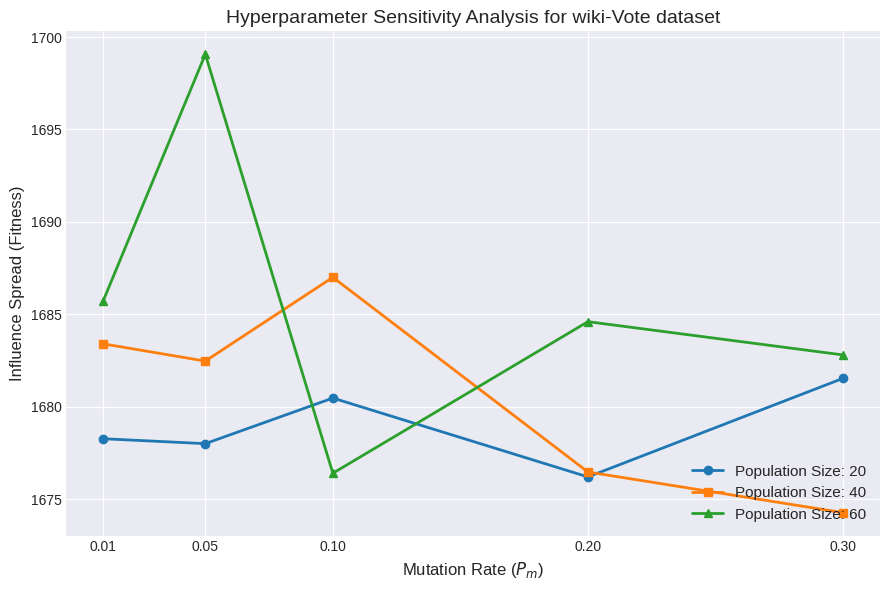

In [ ]:
def tuned_genetic_algorithm(G, k, pop_size, generations, mutation_rate, mc_sims=15):
    all_nodes = list(G.nodes())
    population = [random.sample(all_nodes, k) for _ in range(pop_size)]
    best_spread = 0

    for gen in range(generations):
        fitness_scores = [independent_cascade(G, chromo, 0.1, mc_sims) for chromo in population]
        max_fitness = max(fitness_scores)

        if max_fitness > best_spread:
            best_spread = max_fitness
            best_seed_set = population[fitness_scores.index(max_fitness)]

        next_gen = [best_seed_set] # Elitism

        while len(next_gen) < pop_size:
            p_a = tournament_selection(population, fitness_scores)
            p_b = tournament_selection(population, fitness_scores)
            child = crossover(p_a, p_b, all_nodes, k)

            # --- DYNAMIC MUTATION ---
            if random.random() < mutation_rate:
                drop_idx = random.randint(0, len(child) - 1)
                avail = list(set(all_nodes) - set(child))
                child[drop_idx] = random.choice(avail)

            next_gen.append(child)
        population = next_gen

    return best_spread

mutation_rates = [0.01, 0.05, 0.10, 0.20, 0.30]
population_sizes = [20, 40, 60]
k_target = 8
generations = 10
tuning_results = {pop: [] for pop in population_sizes}
print(f"Starting Grid Search (k={k_target})...")
for pop in population_sizes:
    print(f"Testing Population Size: {pop}")
    for mut in mutation_rates:
        start = time.time()
        spread = tuned_genetic_algorithm(G2, k_target, pop, generations, mut)
        tuning_results[pop].append(spread)
        print(f"  -> Mutation: {mut*100}% | Spread: {spread:.1f} | Time: {time.time()-start:.1f}s")
plt.figure(figsize=(9, 6))
plt.style.use('seaborn-v0_8-darkgrid')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

for idx, pop in enumerate(population_sizes):
    plt.plot(mutation_rates, tuning_results[pop],
             marker=markers[idx], color=colors[idx], linewidth=2,
             label=f'Population Size: {pop}')

plt.title('Hyperparameter Sensitivity Analysis for wiki-Vote dataset', fontsize=14)
plt.xlabel('Mutation Rate ($P_m$)', fontsize=12)
plt.ylabel('Influence Spread (Fitness)', fontsize=12)
plt.xticks(mutation_rates)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

Starting Grid Search (k=8)...
Testing Population Size: 20
  -> Mutation: 1.0% | Spread: 770.3 | Time: 11.5s
  -> Mutation: 5.0% | Spread: 1144.1 | Time: 17.6s
  -> Mutation: 10.0% | Spread: 934.3 | Time: 13.8s
  -> Mutation: 20.0% | Spread: 825.9 | Time: 12.0s
  -> Mutation: 30.0% | Spread: 796.9 | Time: 13.1s
Testing Population Size: 40
  -> Mutation: 1.0% | Spread: 816.5 | Time: 25.6s
  -> Mutation: 5.0% | Spread: 928.6 | Time: 28.3s
  -> Mutation: 10.0% | Spread: 918.5 | Time: 29.3s
  -> Mutation: 20.0% | Spread: 805.5 | Time: 20.6s
  -> Mutation: 30.0% | Spread: 1048.0 | Time: 24.0s
Testing Population Size: 60
  -> Mutation: 1.0% | Spread: 916.3 | Time: 40.1s
  -> Mutation: 5.0% | Spread: 944.9 | Time: 39.9s
  -> Mutation: 10.0% | Spread: 937.8 | Time: 41.3s
  -> Mutation: 20.0% | Spread: 1240.1 | Time: 54.1s
  -> Mutation: 30.0% | Spread: 1009.2 | Time: 47.2s


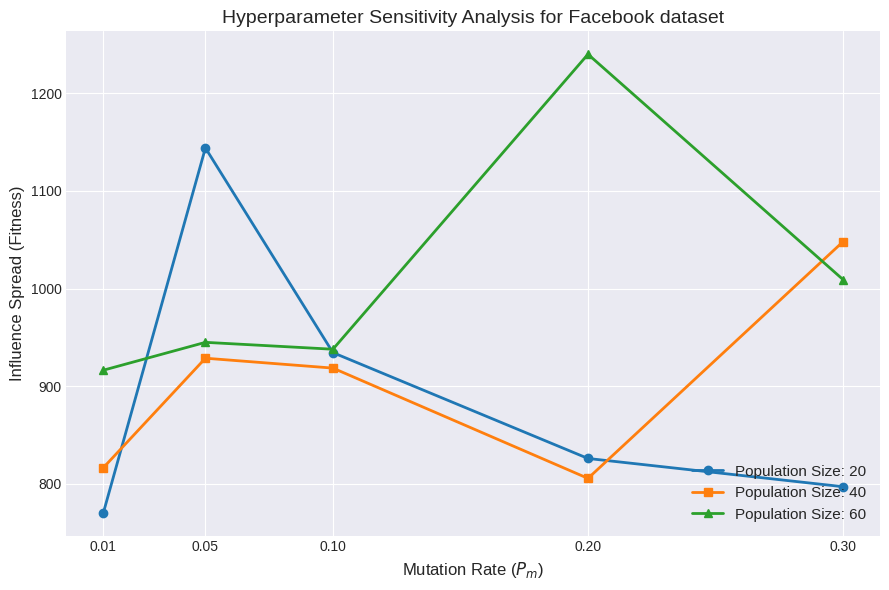

In [ ]:
def tuned_genetic_algorithm(G, k, pop_size, generations, mutation_rate, mc_sims=15):
    all_nodes = list(G.nodes())
    population = [random.sample(all_nodes, k) for _ in range(pop_size)]
    best_spread = 0

    for gen in range(generations):
        fitness_scores = [independent_cascade(G, chromo, 0.1, mc_sims) for chromo in population]
        max_fitness = max(fitness_scores)

        if max_fitness > best_spread:
            best_spread = max_fitness
            best_seed_set = population[fitness_scores.index(max_fitness)]

        next_gen = [best_seed_set] # Elitism

        while len(next_gen) < pop_size:
            p_a = tournament_selection(population, fitness_scores)
            p_b = tournament_selection(population, fitness_scores)
            child = crossover(p_a, p_b, all_nodes, k)

            # --- DYNAMIC MUTATION ---
            if random.random() < mutation_rate:
                drop_idx = random.randint(0, len(child) - 1)
                avail = list(set(all_nodes) - set(child))
                child[drop_idx] = random.choice(avail)

            next_gen.append(child)
        population = next_gen

    return best_spread

mutation_rates = [0.01, 0.05, 0.10, 0.20, 0.30]
population_sizes = [20, 40, 60]
k_target = 8
generations = 10
tuning_results = {pop: [] for pop in population_sizes}
print(f"Starting Grid Search (k={k_target})...")
for pop in population_sizes:
    print(f"Testing Population Size: {pop}")
    for mut in mutation_rates:
        start = time.time()
        spread = tuned_genetic_algorithm(G3, k_target, pop, generations, mut)
        tuning_results[pop].append(spread)
        print(f"  -> Mutation: {mut*100}% | Spread: {spread:.1f} | Time: {time.time()-start:.1f}s")
plt.figure(figsize=(9, 6))
plt.style.use('seaborn-v0_8-darkgrid')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

for idx, pop in enumerate(population_sizes):
    plt.plot(mutation_rates, tuning_results[pop],
             marker=markers[idx], color=colors[idx], linewidth=2,
             label=f'Population Size: {pop}')

plt.title('Hyperparameter Sensitivity Analysis for Facebook dataset', fontsize=14)
plt.xlabel('Mutation Rate ($P_m$)', fontsize=12)
plt.ylabel('Influence Spread (Fitness)', fontsize=12)
plt.xticks(mutation_rates)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()